# Clustering redshifts with *yet_another_wizz*: amplitude fitting and multi-tracer combination

**Author:** Tianqing Zhang

This notebook extends the basic [`10_YAW`](https://github.com/LSSTDESC/rail/blob/main/pipeline_examples/estimation_examples/10_YAW.ipynb)
example to the full clustering-redshift analysis that `rail_yaw` now supports:

1. Measure the reference auto- and cross-correlation functions in **many radial
   bins** (here 30 logarithmic bins from **1 Mpc to 30 Mpc**) instead of a single
   scale.
2. In every redshift bin, fit the measured amplitudes against a model for the
   angular matter correlation function `w_mm` (computed with CCL):
   `w_ss(r) ~ A_ss * w_mm(r)` for the reference autocorrelation and
   `w_sp(r) ~ A_sp * w_mm(r) + C` for the cross-correlation. This is the
   `YawFitAmplitude` stage.
3. Form the clustering redshift estimate `n_cc = A_sp / sqrt(A_ss) / b_p` for each
   reference tracer and **combine several tracers** that cover different,
   partially overlapping redshift ranges by inverse-variance weighting. This is
   the `YawNzCombine` stage, built for a given set of tracers with
   `create_yaw_nz_combine`.

We build **four reference tracers** — `bgs`, `lrg`, `elg`, `qso` — from the same
DC2 test sample by restricting it to different redshift ranges, mimicking a set
of spectroscopic tracers.

**Note:** the result is a ratio of correlation amplitudes, *not* a probability
density; it can scatter below zero and requires further modelling to become a
PDF.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rail.core.data import DataStore, Hdf5Handle
from rail.core.stage import RailStage

# allow re-running cells without clashing on datastore keys
DataStore.allow_overwrite = True

from yaw.randoms import BoxRandoms

from rail.yaw_rail.utils import get_dc2_test_data
from rail.yaw_rail.cosmology import get_ccl_cosmology, matter_template
from rail.estimation.algos.cc_yaw import (
    create_yaw_cache_alias,
    YawCacheCreate,
    YawAutoCorrelate,
    YawCrossCorrelate,
    YawFitAmplitude,
    create_yaw_nz_combine,
)

VERBOSE = "error"    # yaw log level; set to "info"/"debug" to see progress
MAX_WORKERS = 16     # parallel workers for pair counting

# Measuring out to 30 Mpc means counting pairs over degree-scale angular
# separations, which is expensive. To keep this example fast we sub-sample the
# 100k DC2 catalogue; a production run would use the full sample (and many more
# spatial patches).
DOWNSAMPLE = 30_000
RAND_MULT = 10       # number of randoms per data object

## Configuration

The correlation amplitude is measured in 30 logarithmic radial bins between 1 and
30 Mpc. Both correlate stages accept a *sequence* of scale limits (`rmin`/`rmax`),
one entry per radial bin.

The four tracers share a common `dz = 0.1` redshift grid (bin edges at
`0.2 + 0.1 k`) so that the inverse-variance combination can match bins where their
ranges overlap.

In [2]:
# 30 log-spaced radial bins from 1 to 30 Mpc
SCALE_EDGES = np.logspace(np.log10(1.0), np.log10(30.0), 31)
UNIT = "Mpc"

corr_config = dict(
    rmin=SCALE_EDGES[:-1].tolist(),
    rmax=SCALE_EDGES[1:].tolist(),
    unit=UNIT,
    max_workers=MAX_WORKERS,
    verbose=VERBOSE,
)

# reference tracers: same sample restricted to different redshift ranges
TRACERS = ["bgs", "lrg", "elg", "qso"]
TRACER_ZLIM = {
    "bgs": (0.2, 0.5),
    "lrg": (0.4, 1.2),
    "elg": (0.8, 1.6),
    "qso": (0.8, 1.8),
}
ZBIN_WIDTH = 0.1


def zbins(tracer):
    zmin, zmax = TRACER_ZLIM[tracer]
    return dict(zmin=zmin, zmax=zmax, num_bins=round((zmax - zmin) / ZBIN_WIDTH))


# fiducial cosmology for the matter model (eisenstein_hu transfer function -> no camb needed)
cosmo = get_ccl_cosmology("Planck15")

# scale cut used by the amplitude fit, in the measurement unit (Mpc)
fit_config = dict(
    fit_rmin=1.0,
    fit_rmax=30.01,
    auto_fit_rmin=2.0,
    auto_fit_rmax=30.01,
    use_jk_cov=False,   # diagonal WLS: always invertible with few patches
    fit_constant=True,  # fit A_sp and an additive constant C for the cross-correlation
    verbose=VERBOSE,
)
print({t: zbins(t) for t in TRACERS})

{'bgs': {'zmin': 0.2, 'zmax': 0.5, 'num_bins': 3}, 'lrg': {'zmin': 0.4, 'zmax': 1.2, 'num_bins': 8}, 'elg': {'zmin': 0.8, 'zmax': 1.6, 'num_bins': 8}, 'qso': {'zmin': 0.8, 'zmax': 1.8, 'num_bins': 10}}


## Data preparation

We download the DC2 test sample (100k objects, `0.2 < z < 1.8`), sub-sample it to
`DOWNSAMPLE` objects for speed, and use that as the common **unknown** sample. For
each reference tracer we take the subset of the same catalogue that falls in the
tracer's redshift range, together with a matching subset of uniform randoms
(`RAND_MULT`x the data), so that the reference randoms share the reference redshift
distribution.

In [3]:
test_data = get_dc2_test_data()
if DOWNSAMPLE is not None and DOWNSAMPLE < len(test_data):
    test_data = test_data.sample(n=DOWNSAMPLE, random_state=1).reset_index(drop=True)
redshifts = test_data["z"].to_numpy()
n_data = len(test_data)

# uniform randoms over the data footprint, redshifts cloned from the data
generator = BoxRandoms(
    test_data["ra"].min(),
    test_data["ra"].max(),
    test_data["dec"].min(),
    test_data["dec"].max(),
    redshifts=redshifts,
    seed=12345,
)
test_rand = generator.generate_dataframe(n_data * RAND_MULT)
test_rand.rename(columns=dict(redshifts="z"), inplace=True)

# the full sample is the (common) unknown sample
handle_unk_data = Hdf5Handle("unk_data", data=test_data)
handle_unk_rand = Hdf5Handle("unk_rand", data=test_rand)


def tracer_handles(tracer):
    zmin, zmax = TRACER_ZLIM[tracer]
    data = test_data[(test_data["z"] >= zmin) & (test_data["z"] < zmax)]
    rand = test_rand[(test_rand["z"] >= zmin) & (test_rand["z"] < zmax)]
    return (
        Hdf5Handle(f"{tracer}_data", data=data.reset_index(drop=True)),
        Hdf5Handle(f"{tracer}_rand", data=rand.reset_index(drop=True)),
    )


print(f"unknown sample: N={n_data}, {redshifts.min():.2f} < z < {redshifts.max():.2f}")
for t in TRACERS:
    d, _ = tracer_handles(t)
    print(f"  {t}: N={len(d.data)}, z in {TRACER_ZLIM[t]}")

unknown sample: N=30000, 0.20 < z < 1.80
  bgs: N=4714, z in (0.2, 0.5)
  lrg: N=18178, z in (0.4, 1.2)
  elg: N=16512, z in (0.8, 1.6)
  qso: N=18724, z in (0.8, 1.8)


## Caching and consistent spatial patches

*yet_another_wizz* uses spatial (jackknife) resampling, so every catalogue must be
split into the **same** patches. We create the unknown cache first with
`patch_num=10`, which defines ten patch centers, and then create each reference
cache with `patch_source` pointing at the unknown cache so that all catalogues
adopt the same centers.

Ten patches is small (chosen to keep this example fast); a real analysis uses many
more. With so few patches we fit the amplitude with diagonal weighted least
squares (`use_jk_cov=False`), which is robust when the number of patches does not
exceed the number of radial bins.

In [4]:
cache_unk = YawCacheCreate.make_stage(
    name="cache_unk",
    aliases=create_yaw_cache_alias("unk"),
    path="run/example_unk",
    overwrite=True,
    ra_name="ra",
    dec_name="dec",
    patch_num=10,   # defines the patch centers shared by all caches
    max_workers=MAX_WORKERS,
    verbose=VERBOSE,
).create(
    data=handle_unk_data,
    rand=handle_unk_rand,
)

cache_ref = {}
for tracer in TRACERS:
    data_h, rand_h = tracer_handles(tracer)
    cache_ref[tracer] = YawCacheCreate.make_stage(
        name=f"cache_{tracer}",
        aliases=create_yaw_cache_alias(tracer),
        path=f"run/example_{tracer}",
        overwrite=True,
        ra_name="ra",
        dec_name="dec",
        redshift_name="z",
        max_workers=MAX_WORKERS,
        verbose=VERBOSE,
    ).create(
        data=data_h,
        rand=rand_h,
        patch_source=cache_unk,   # adopt the patch centers of the unknown cache
    )
print("created caches:", ["unk"] + list(cache_ref))

2026-07-15 14:47:53 [info     ] Inserting handle into data store.  data_unk: None, cache_unk


2026-07-15 14:47:53 [info     ] Inserting handle into data store.  rand_unk: None, cache_unk


YAW | yet_another_wizz v3.1.2


2026-07-15 14:47:53 [info     ] Inserting handle into data store.  patch_source_unk: None, cache_unk


2026-07-15 14:48:18 [info     ] Inserting handle into data store.  output_cache_unk: inprogress_output_cache_unk.path, cache_unk


...

2026-07-15 14:49:31 [info     ] Inserting handle into data store.  rand_qso: None, cache_qso


2026-07-15 14:49:31 [info     ] Inserting handle into data store.  patch_source_qso: None, cache_qso


YAW | yet_another_wizz v3.1.2


2026-07-15 14:49:55 [info     ] Inserting handle into data store.  output_cache_qso: inprogress_output_cache_qso.path, cache_qso


created caches: ['unk', 'bgs', 'lrg', 'elg', 'qso']


## Measure the correlations and fit the amplitudes

For each tracer we measure the reference autocorrelation and the cross-correlation
with the unknown sample (both in the 30 radial bins defined above), then run
`YawFitAmplitude`, which fits `A_ss`, `A_sp` and the constant `C` in every redshift
bin and estimates their uncertainties from the patch jackknife.

In [5]:
auto_h, cross_h, fit_h = {}, {}, {}

for tracer in TRACERS:
    auto_h[tracer] = YawAutoCorrelate.make_stage(
        name=f"auto_{tracer}", **corr_config, **zbins(tracer),
    ).correlate(sample=cache_ref[tracer])

    cross_h[tracer] = YawCrossCorrelate.make_stage(
        name=f"cross_{tracer}", **corr_config, **zbins(tracer),
    ).correlate(reference=cache_ref[tracer], unknown=cache_unk)

    fit_h[tracer] = YawFitAmplitude.make_stage(
        name=f"fit_{tracer}", **fit_config,
    ).fit(cross_corr=cross_h[tracer], auto_corr_ref=auto_h[tracer])

    fit = fit_h[tracer].data
    print(f"{tracer}: fitted {len(fit.redshift)} redshift bins, "
          f"A_sp range [{fit.amp_cross.min():.3g}, {fit.amp_cross.max():.3g}]")

2026-07-15 14:49:55 [info     ] Inserting handle into data store.  output_cache_bgs: None, auto_bgs


YAW | yet_another_wizz v3.1.2


2026-07-15 14:50:18 [info     ] Inserting handle into data store.  output_auto_bgs: inprogress_output_auto_bgs.hdf5, auto_bgs


2026-07-15 14:50:18 [info     ] Inserting handle into data store.  output_cache_bgs: None, cross_bgs


2026-07-15 14:50:18 [info     ] Inserting handle into data store.  output_cache_unk: None, cross_bgs


...

2026-07-15 14:54:23 [info     ] Inserting handle into data store.  output_cross_qso: None, fit_qso


2026-07-15 14:54:23 [info     ] Inserting handle into data store.  output_auto_qso: None, fit_qso


YAW | yet_another_wizz v3.1.2


2026-07-15 14:54:23 [info     ] Inserting handle into data store.  output_fit_qso: inprogress_output_fit_qso.hdf5, fit_qso


qso: fitted 10 redshift bins, A_sp range [-0.0651, 0.298]


## Figure 1 & 2: does the amplitude fit work?

For every tracer and a few representative redshift bins we overlay the measured
correlation amplitudes (points with jackknife errorbars) and the best-fit model.
If the fit works, the model curve tracks the measured points over the fitted
scale range (to the right of the dashed scale-cut line).

In [6]:
def measured_w(scaled):
    """Stack the resampled correlation amplitude and its error over radial bins.

    Returns two arrays of shape (num_scales, num_zbins).
    """
    corrdata = [cf.sample() for cf in scaled.corrfuncs]
    w = np.array([cd.data for cd in corrdata])
    werr = np.array([cd.error for cd in corrdata])
    return w, werr


def representative_zbins(num_zbins, ncol=6):
    """Evenly spaced redshift-bin indices, at most `ncol` of them."""
    n = min(ncol, num_zbins)
    return np.unique(np.round(np.linspace(0, num_zbins - 1, n)).astype(int))


NCOL = 6

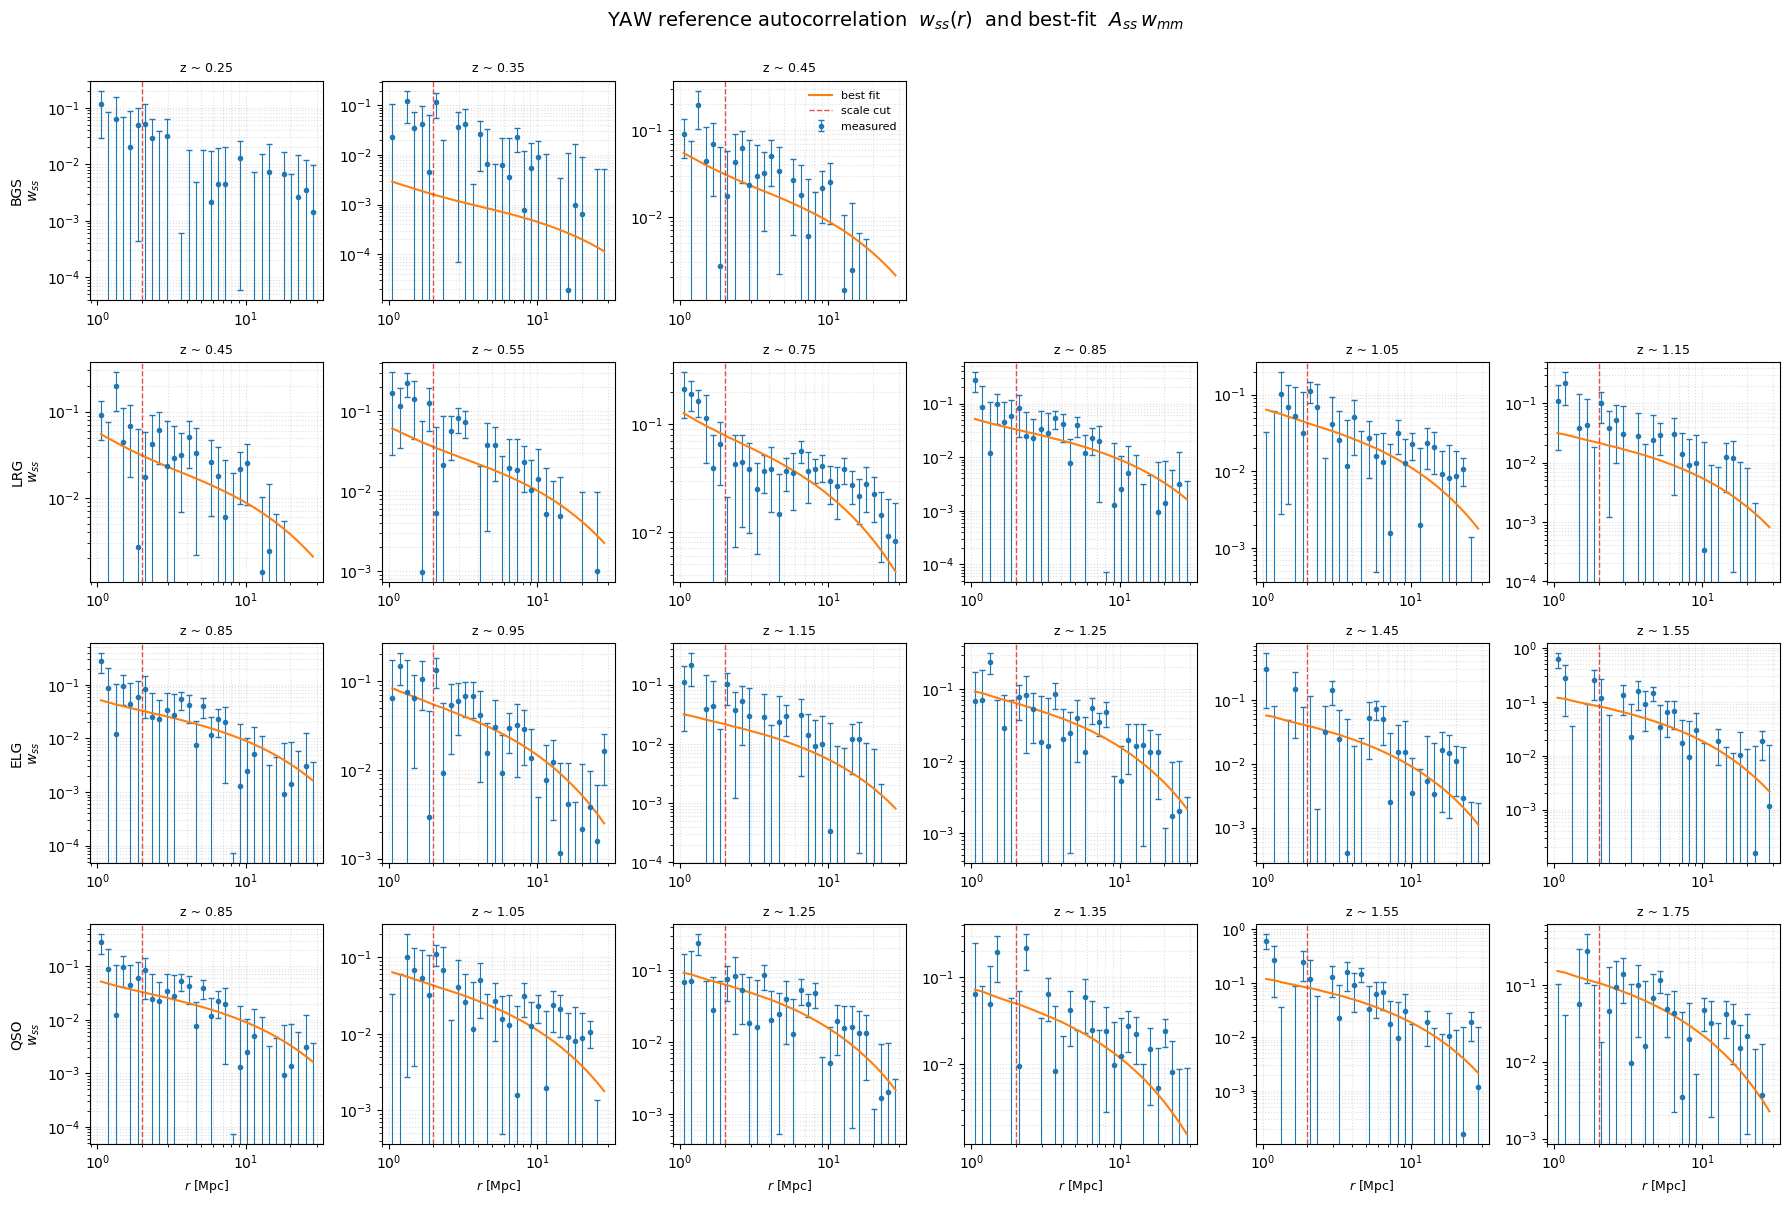

In [7]:
# ---------- Figure 1: reference autocorrelation w_ss ----------
fig, axes = plt.subplots(len(TRACERS), NCOL, figsize=(18, 12))
fig.suptitle(r"YAW reference autocorrelation  $w_{ss}(r)$  and best-fit  $A_{ss}\,w_{mm}$",
             fontsize=14, y=1.0)

for row, tracer in enumerate(TRACERS):
    scaled = auto_h[tracer].data
    fit = fit_h[tracer].data
    rc = scaled.r_center
    w, werr = measured_w(scaled)
    w_mm = matter_template(scaled, cosmo)  # (num_zbins, num_scales)
    sel = representative_zbins(len(fit.redshift), NCOL)

    for col in range(NCOL):
        ax = axes[row, col]
        if col >= len(sel):
            ax.set_visible(False)
            continue
        j = sel[col]
        model = fit.amp_auto[j] * w_mm[j, :]
        ax.errorbar(rc, w[:, j], werr[:, j], fmt="o", ms=3, capsize=2, lw=0.8,
                    color="C0", label="measured")
        ax.plot(rc, model, lw=1.5, color="C1", label="best fit")
        ax.axvline(fit_config["auto_fit_rmin"], ls="--", lw=1.0, color="C3",
                   alpha=0.8, label="scale cut")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"z ~ {fit.redshift[j]:.2f}", fontsize=9)
        ax.grid(True, which="both", ls=":", alpha=0.4)
        if col == 0:
            ax.set_ylabel(f"{tracer.upper()}\n$w_{{ss}}$", fontsize=10)
        if row == len(TRACERS) - 1:
            ax.set_xlabel(r"$r$ [Mpc]", fontsize=9)
        if row == 0 and col == len(sel) - 1:
            ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

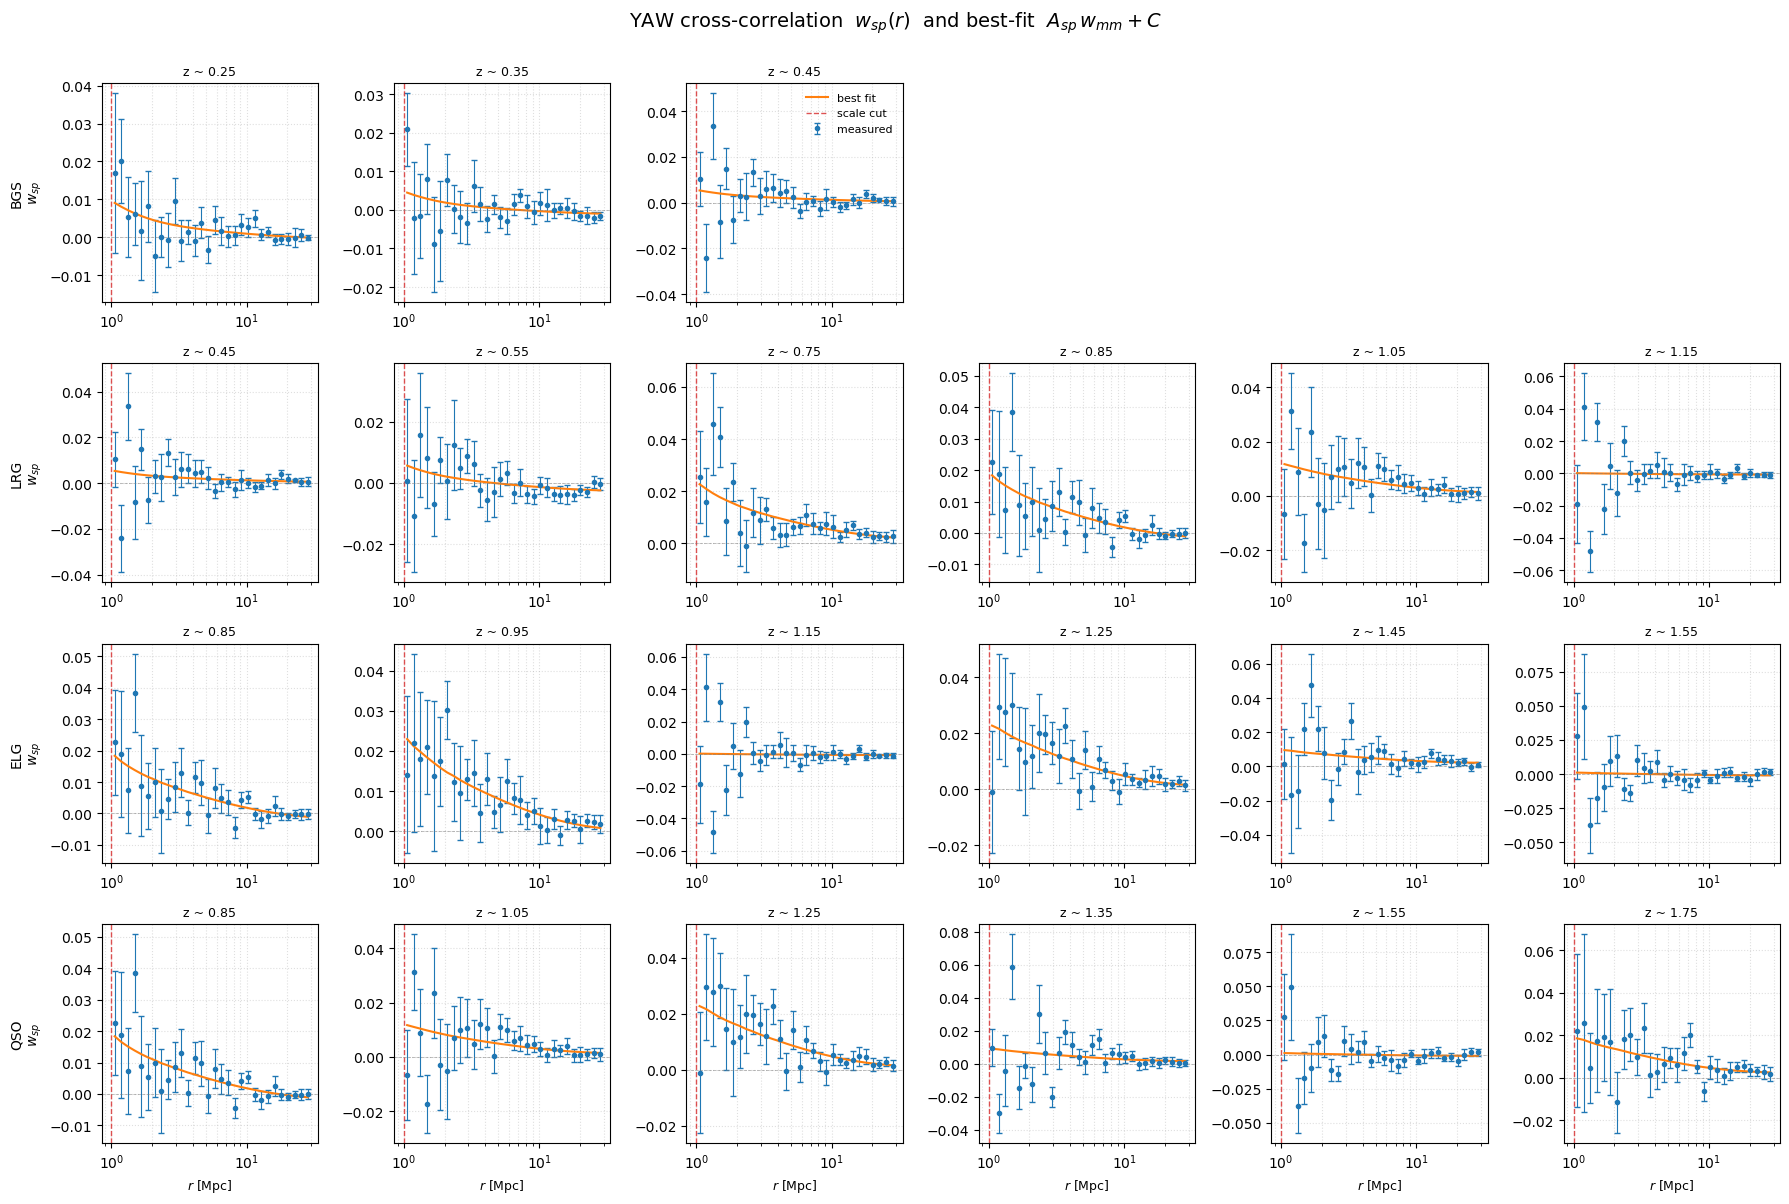

In [8]:
# ---------- Figure 2: cross-correlation w_sp ----------
fig, axes = plt.subplots(len(TRACERS), NCOL, figsize=(18, 12))
fig.suptitle(r"YAW cross-correlation  $w_{sp}(r)$  and best-fit  $A_{sp}\,w_{mm} + C$",
             fontsize=14, y=1.0)

for row, tracer in enumerate(TRACERS):
    scaled = cross_h[tracer].data
    fit = fit_h[tracer].data
    rc = scaled.r_center
    w, werr = measured_w(scaled)
    w_mm = matter_template(scaled, cosmo)
    sel = representative_zbins(len(fit.redshift), NCOL)

    for col in range(NCOL):
        ax = axes[row, col]
        if col >= len(sel):
            ax.set_visible(False)
            continue
        j = sel[col]
        const = 0.0 if fit.const_cross is None else fit.const_cross[j]
        model = fit.amp_cross[j] * w_mm[j, :] + const
        ax.errorbar(rc, w[:, j], werr[:, j], fmt="o", ms=3, capsize=2, lw=0.8,
                    color="C0", label="measured")
        ax.plot(rc, model, lw=1.5, color="C1", label="best fit")
        ax.axvline(fit_config["fit_rmin"], ls="--", lw=1.0, color="C3",
                   alpha=0.8, label="scale cut")
        ax.axhline(0.0, lw=0.6, ls="--", color="gray", alpha=0.6)
        ax.set_xscale("log")
        ax.set_title(f"z ~ {fit.redshift[j]:.2f}", fontsize=9)
        ax.grid(True, which="both", ls=":", alpha=0.4)
        if col == 0:
            ax.set_ylabel(f"{tracer.upper()}\n$w_{{sp}}$", fontsize=10)
        if row == len(TRACERS) - 1:
            ax.set_xlabel(r"$r$ [Mpc]", fontsize=9)
        if row == 0 and col == len(sel) - 1:
            ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

## Combine the tracers into a single n(z)

`create_yaw_nz_combine` builds a summarizer stage with one input per tracer. It
forms `n_cc = A_sp / sqrt(A_ss) / b_p` for each tracer — with the unknown-sample
bias evolution `b_p = 1 / D(z)` (`bias_mode="growth_factor"`) — and combines the
tracers by inverse-variance weighting where their redshift ranges overlap.

We turn off the built-in normalisation here (`normalize=False`) so that the
per-tracer estimates and the combined estimate share a common amplitude scale for
plotting; the plot applies a single display normalisation to all curves.

In [9]:
YawNzCombine = create_yaw_nz_combine(TRACERS)

nz_h = YawNzCombine.make_stage(
    name="combine",
    bias_mode="growth_factor",
    normalize=False,
    verbose=VERBOSE,
).combine(**{f"fit_{t}": fit_h[t] for t in TRACERS})

nz = nz_h.data
print("combined redshift bins:", np.round(nz.redshift, 3))
print("all errors positive:", bool(np.all(nz.nz_err > 0)))

2026-07-15 14:54:32 [info     ] Inserting handle into data store.  output_fit_bgs: None, combine


2026-07-15 14:54:32 [info     ] Inserting handle into data store.  output_fit_lrg: None, combine


2026-07-15 14:54:32 [info     ] Inserting handle into data store.  output_fit_elg: None, combine


2026-07-15 14:54:32 [info     ] Inserting handle into data store.  output_fit_qso: None, combine


YAW | yet_another_wizz v3.1.2


2026-07-15 14:54:32 [info     ] Inserting handle into data store.  output_combine: inprogress_output_combine.hdf5, combine


combined redshift bins: [0.35 0.45 0.55 0.65 0.75 0.85 0.95 1.05 1.15 1.25 1.35 1.45 1.55 1.65
 1.75]
all errors positive: True


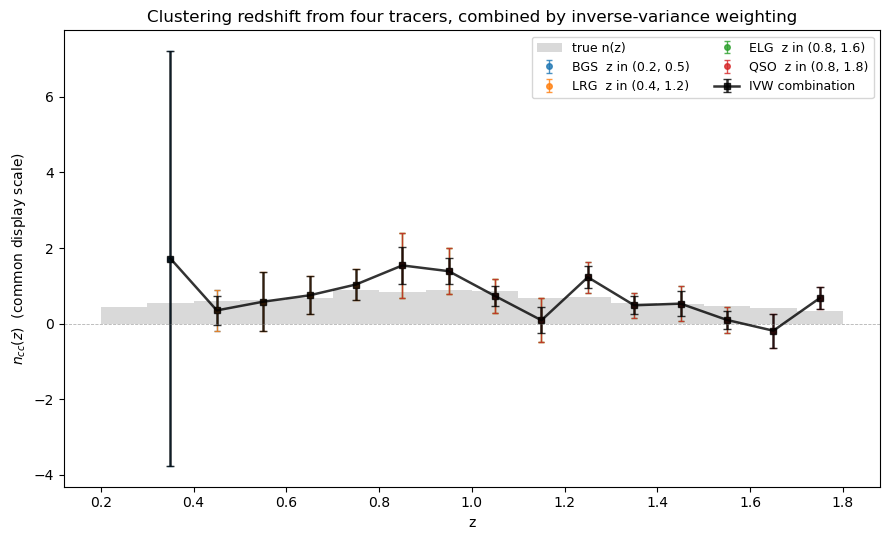

In [10]:
# ---------- Figure 3: per-tracer n_cc and the inverse-variance combination ----------
# single display normalisation shared by every curve
norm = 1.0 / np.trapezoid(np.clip(nz.nz, 0.0, None), nz.redshift)

plt.figure(figsize=(9, 5.5))

# true redshift distribution of the unknown sample, for reference
plt.hist(test_data["z"], bins=np.arange(0.2, 1.81, ZBIN_WIDTH), density=True,
         color="0.85", label="true n(z)")

for tracer in TRACERS:
    tr = nz.tracers[tracer]
    plt.errorbar(tr["z"], tr["nz"] * norm, yerr=tr["nz_err"] * norm,
                 fmt="o", ms=4, lw=1, capsize=2, alpha=0.8,
                 label=f"{tracer.upper()}  z in {TRACER_ZLIM[tracer]}")

plt.errorbar(nz.redshift, nz.nz * norm, yerr=nz.nz_err * norm,
             fmt="s-", ms=5, lw=1.8, color="black", alpha=0.8, capsize=3,
             label="IVW combination")

plt.axhline(0.0, lw=0.6, ls="--", color="gray", alpha=0.6)
plt.xlabel("z")
plt.ylabel(r"$n_{cc}(z)$  (common display scale)")
plt.title("Clustering redshift from four tracers, combined by inverse-variance weighting")
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## Clean up the caches

The cached catalogues are written to disk and are not removed automatically, since
a reference cache can be reused across tomographic bins. Here we drop them all.

In [11]:
cache_unk.data.drop()
for tracer in TRACERS:
    cache_ref[tracer].data.drop()
print("dropped all caches")

dropped all caches
